In [1]:
import importlib
import sys
sys.path.append('../code')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature


import SeaLevelContrib as slc

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

In [2]:
importlib.reload(slc)

<module 'SeaLevelContrib' from 'C:\\Users\\kyrab\\Github\\SLBudget\\notebooks\\../code\\SeaLevelContrib.py'>

In [3]:
def rotate_longitude(ds):
    '''Rotate the longitude of an xarray dataset from [0,360] to [-180,180]'''
    
    if 'lon' in ds.dims:
        lon = 'lon'
    elif 'longitude' in ds.dims:
        lon = 'longitude'
    else:
        print('Longitude not found in dimensions')
        
    ds[lon] = np.where(ds[lon]>180, ds[lon]-360, ds[lon])
    ds = ds.reindex({ lon : np.sort(ds[lon])})
    
    return ds


In [4]:
fred_dir = '../data/Frederikse2020/'
Fred_ant_ds = xr.open_dataset(f'{fred_dir}AIS.nc')

fred2 = rotate_longitude(Fred_ant_ds)

Gravis_dir = '../outputs/Gravis_Antarctica/'
Gravis_ant_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Ant_clean.nc')
#display(Gravis_ant_ds)
Gravis_gre_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Gre_clean.nc')


#Optional: scale data by factor 1.2 or 1.1837950465122913
#Gravis_ant_ds['AIS_Gravis'] = Gravis_ant_ds['AIS_Gravis']*1.1837950465122913
#Gravis_ant_ds['Meanslr'] = Gravis_ant_ds['Meanslr']*1.1837950465122913


In [5]:
# Define the tide gauge stations that are used: 
tg_id = [20, 22, 23, 24, 25, 32]

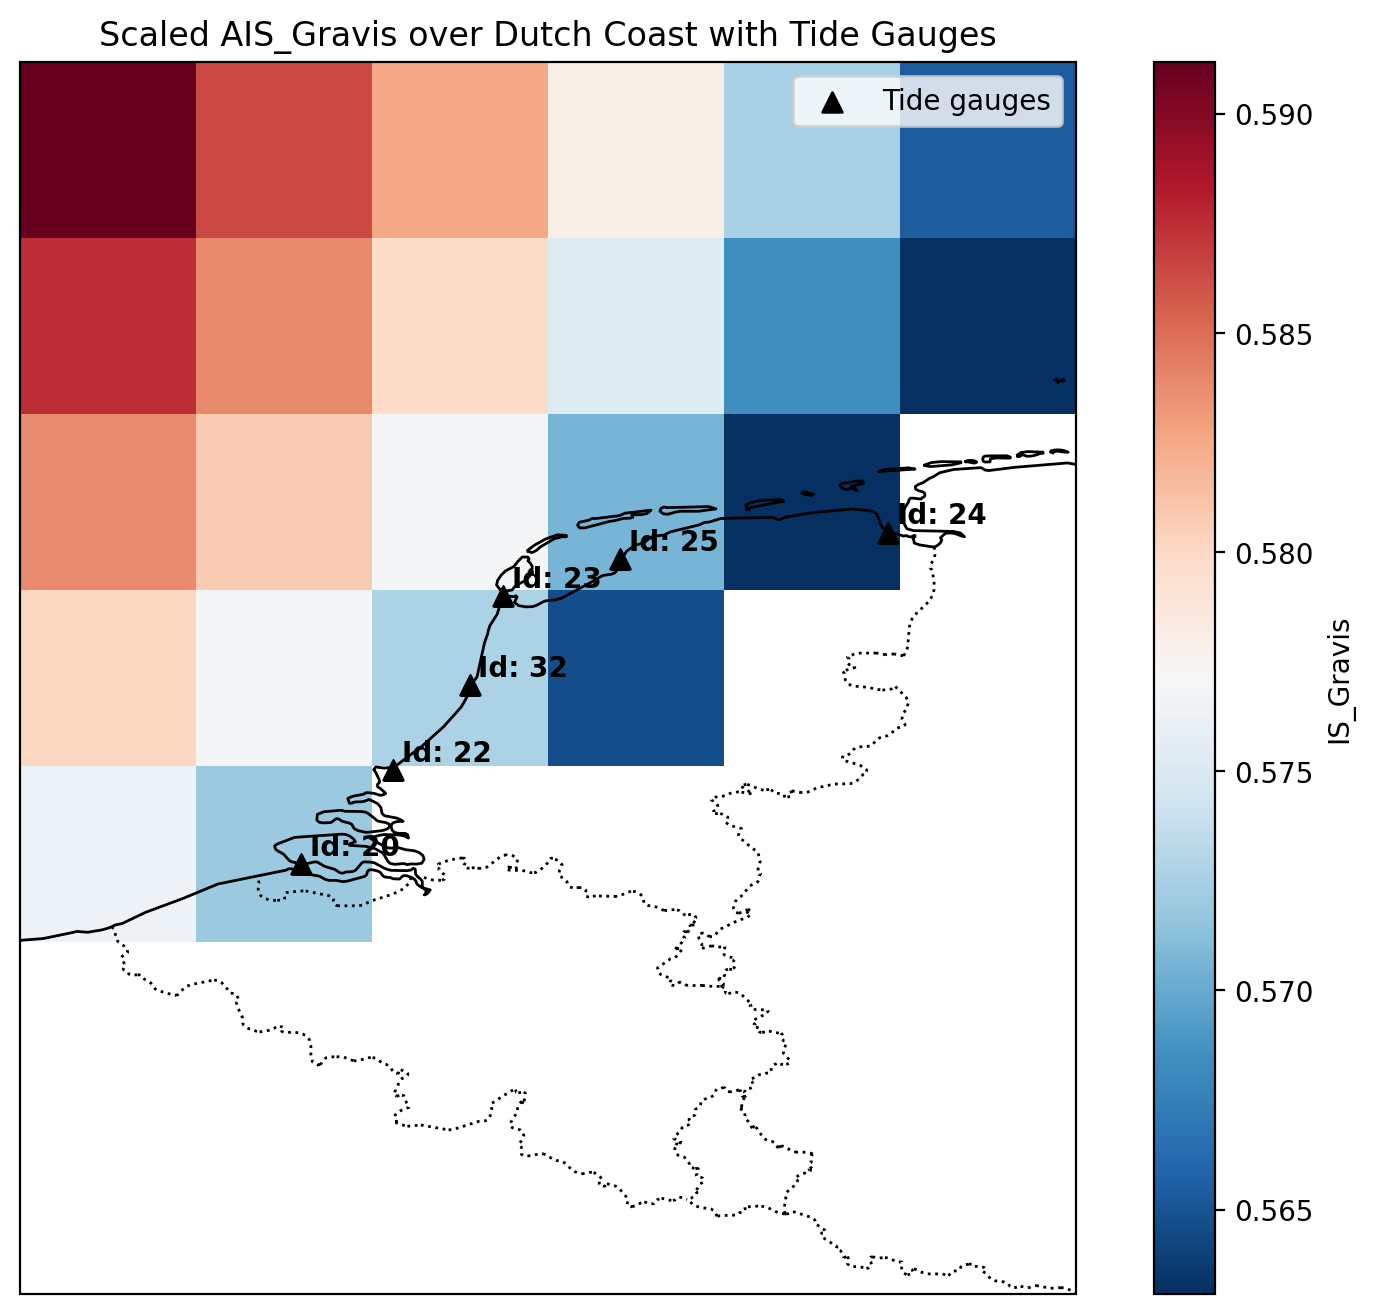

In [6]:
# Extract coordinates
tg_coords = [slc.tg_lat_lon(tg) for tg in tg_id]
tg_lats = [c[0] for c in tg_coords]
tg_lons = [c[1] for c in tg_coords]


# Define region (Dutch coast)
lon_min, lon_max = 2,8 #3, 7
lat_min, lat_max = 49, 56 #51, 54

# Select region
da_region = Gravis_ant_ds['IS_Gravis'].sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_min, lat_max)
)

# Pick a specific time if dataset has time dimension
if 'time' in da_region.dims:
    da_region = da_region.isel(time=-1)#-da_region.isel(time=0)  # Last time step minus first timestep (first timestep is already 0 so no need for that) 

# Plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot GRAVIS data
im = da_region.plot(ax=ax, cmap='RdBu_r', add_colorbar=True)

# Add coastlines and borders
ax.coastlines(resolution='10m', zorder = 1 )
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot tide gauge stations
ax.scatter(tg_lons, tg_lats, color='black', s=50, marker='^', label='Tide gauges', zorder=10)

# Add tide gauge IDs as labels
for lon, lat, tg in zip(tg_lons, tg_lats, tg_id):
    ax.text(lon + 0.05, lat + 0.05, 'Id: ' + str(tg), color='black', fontsize=10, weight='bold', zorder=10)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.set_title('Scaled AIS_Gravis over Dutch Coast with Tide Gauges')
ax.legend()

plt.show()


In [7]:
#Extract latitude and longitude from a tide gauge station from the list. 
tg_coord = slc.tg_lat_lon(tg_id[0])
print(tg_coord)

TWS = slc.contrib_frederikse2020(tg_coord, 'tws', extrap=True)
ANT = slc.contrib_frederikse2020(tg_coord, 'AIS', extrap=True)
GRE = slc.contrib_frederikse2020(tg_coord, 'GrIS', extrap=True)
GLA = slc.contrib_frederikse2020(tg_coord, 'glac', extrap=True)

glo_steric_df = slc.contrib_frederikse2020_glob('GloSteric', extrap=True)


ds = Gravis_ant_ds
ds2 = Gravis_gre_ds

sel_da = ds['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
sel_da2 = ds2['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
# Convert from mm to cm not needed because is already in cm

loc_da = sel_da.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')
loc_da2 = sel_da2.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')

fr_name = {'tws' : 'TWS', 
       'AIS' : 'Antarctica', 
       'GrIS' : 'Greenland', 
       'glac' : 'Glaciers',
          'grav': 'Ant_gravis',
          'grav2': 'Gre_gravis'}


GRAVANT = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav'])    
GRAVGRE = loc_da2.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav2'])    

''' 
EXTRAPOLATE OPTION
nby = 10
trend = np.polyfit(GRAVANT.index[-nby:], GRAVANT.iloc[-nby:], 1)
for i in range(7):
    GRAVANT.loc[GRAVANT.index.max() + 1] = (trend[1]+trend[0]*(GRAVANT.index.max()+1))
'''

#display(GRAVANT*1.1837950465122913)
#display(ANT)


(np.float64(51.442222), np.float64(3.596111))


' \nEXTRAPOLATE OPTION\nnby = 10\ntrend = np.polyfit(GRAVANT.index[-nby:], GRAVANT.iloc[-nby:], 1)\nfor i in range(7):\n    GRAVANT.loc[GRAVANT.index.max() + 1] = (trend[1]+trend[0]*(GRAVANT.index.max()+1))\n'

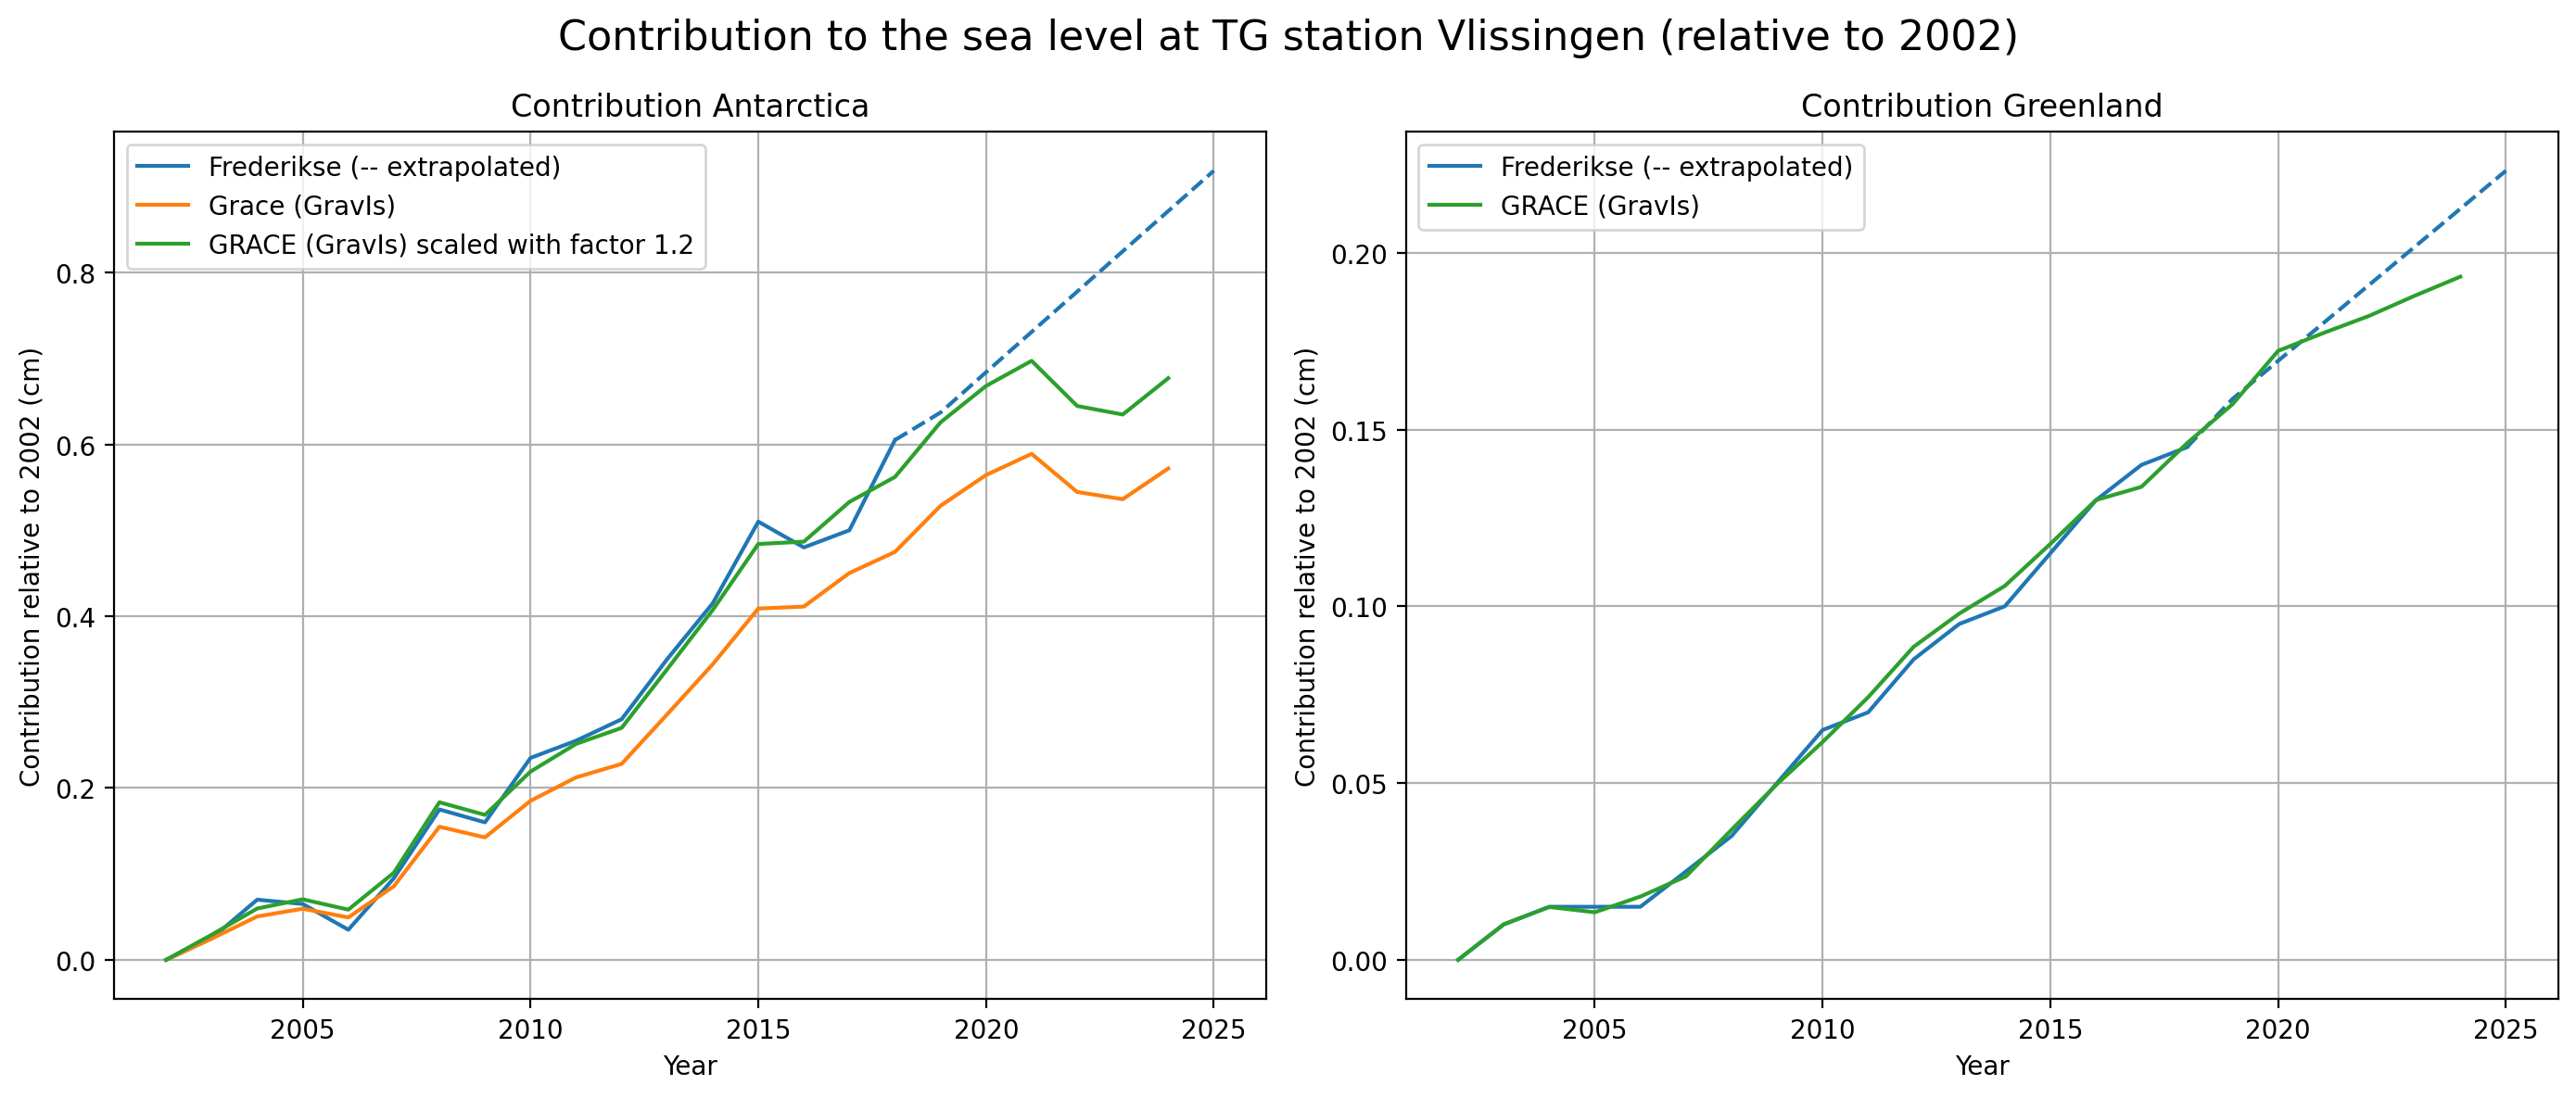

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Antarctica
ax1.plot((ANT - ANT.loc[2002, "Antarctica"]).loc[2002:2018], label='Frederikse (-- extrapolated)', color='tab:blue')
ax1.plot((ANT - ANT.loc[2002, "Antarctica"]).loc[2018:], color='tab:blue', linestyle='--')
ax1.plot(GRAVANT.loc[2002:], label='Grace (GravIs) ', color='tab:orange')
ax1.plot(GRAVANT.loc[2002:] * 1.1837950465122913, label='GRACE (GravIs) scaled with factor 1.2', color='tab:green')

ax1.set_title('Contribution Antarctica')
ax1.set_xlabel('Year')
ax1.set_ylabel('Contribution relative to 2002 (cm)')
ax1.grid(True)
ax1.legend()


# Greenland 
ax2.plot((GRE - GRE.loc[2002, "Greenland"]).loc[2002:2018], label='Frederikse (-- extrapolated)', color='tab:blue')
ax2.plot((GRE - GRE.loc[2002, "Greenland"]).loc[2018:], color='tab:blue', linestyle='--')
ax2.plot(GRAVGRE.loc[2002:], label='GRACE (GravIs)', color='tab:green')

ax2.set_title('Contribution Greenland')
ax2.set_xlabel('Year')
ax2.set_ylabel('Contribution relative to 2002 (cm)')
ax2.grid(True)
ax2.legend()


fig.suptitle('Contribution to the sea level at TG station Vlissingen (relative to 2002)', fontsize=16)

plt.tight_layout()
plt.show()




In [9]:
# Now for all stations and for antarctica, use the factor of 1.18. 

Gravis_ant_ds['IS_Gravis'] = Gravis_ant_ds['IS_Gravis']*1.1837950465122913
Gravis_ant_ds['Meanslr'] = Gravis_ant_ds['Meanslr']*1.1837950465122913

all_TWS = []
all_ANT = []
all_GRE = []
all_GLA = []
all_GRAVANT = []
all_GRAVGRE = []

for tg in tg_id: 
    tg_coord = slc.tg_lat_lon(tg)

    # Contributions from Frederikse 2020
    TWS_tg = slc.contrib_frederikse2020(tg_coord, 'tws', extrap=True)
    ANT_tg = slc.contrib_frederikse2020(tg_coord, 'AIS', extrap=True)
    GRE_tg = slc.contrib_frederikse2020(tg_coord, 'GrIS', extrap=True)
    GLA_tg = slc.contrib_frederikse2020(tg_coord, 'glac', extrap=True)

    all_TWS.append(TWS)
    all_ANT.append(ANT)
    all_GRE.append(GRE)
    all_GLA.append(GLA)

    sel_da = ds['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
    sel_da2 = ds2['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
    # Convert from mm to cm not needed because is already in cm

    loc_da = sel_da.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')
    loc_da2 = sel_da2.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')

    fr_name = {
        'tws' : 'TWS', 
        'AIS' : 'Antarctica', 
        'GrIS' : 'Greenland', 
        'glac' : 'Glaciers',
        'grav': 'Ant_gravis',
        'grav2': 'Gre_gravis'}

    # Was not here oeps.. GRAVANT = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav'])
    GRAVANT = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav'])    
    GRAVGRE = loc_da2.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav2'])  


    #display(GRAVANT*1.1837950465122913)
    
    all_GRAVANT.append(GRAVANT)
    all_GRAVGRE.append(GRAVGRE)


#display(all_GRAVANT) 

# Helper function to compute mean across tide gauges
def mean_across_gauges(list_of_series):
    return pd.concat(list_of_series, axis=1).mean(axis=1)

# Compute mean time series for each contribution
mean_TWS = mean_across_gauges(all_TWS)
mean_ANT = mean_across_gauges(all_ANT)
mean_GRE = mean_across_gauges(all_GRE)
mean_GLA = mean_across_gauges(all_GLA)
mean_GRAVANT = mean_across_gauges(all_GRAVANT)
mean_GRAVGRE = mean_across_gauges(all_GRAVGRE)

# Combine all mean series into a single dataframe
mean_df = pd.DataFrame({
    'TWS_mean': mean_TWS,
    'Antarctica_mean': mean_ANT,
    'Greenland_mean': mean_GRE,
    'Glaciers_mean': mean_GLA,
    'Ant_gravis_mean': mean_GRAVANT,
    'Gre_gravis_mean': mean_GRAVGRE
})


# Ensure the index is numeric or datetime
mean_df.index = pd.to_numeric(mean_df.index, errors='coerce')


display(mean_df.loc[2002:])

,TWS_mean,Antarctica_mean,Greenland_mean,Glaciers_mean,Ant_gravis_mean,Gre_gravis_mean
time,,,,,,
2002,0.185000,-0.250000,-0.065000,-0.335000,0.000000,0.000000
2003,0.085000,-0.225000,-0.055000,-0.280000,0.029048,0.009851
2004,0.000000,-0.180000,-0.050000,-0.220000,0.059572,0.013824
2005,0.120000,-0.185000,-0.050000,-0.180000,0.070121,0.011643
2006,-0.010000,-0.215000,-0.050000,-0.120000,0.058111,0.015205
2007,-0.025000,-0.155000,-0.040000,-0.080000,0.101027,0.019718
2008,-0.060000,-0.075000,-0.030000,-0.050000,0.183176,0.032020
2009,-0.090000,-0.090000,-0.015000,-0.005000,0.168140,0.044154
2010,0.055000,-0.015000,0.000000,0.060000,0.218463,0.054499


In [10]:
Ant_combined = mean_df['Antarctica_mean'].copy()
#display(Ant_combined.loc[2002:2024])
Ant_combined.loc[2002:] = ((mean_df['Ant_gravis_mean'] + mean_df['Antarctica_mean'].loc[2002]) + mean_df['Antarctica_mean'])/2  #takes the mean where there is data twice
#display(Ant_combined.loc[2002:2024])
Ant_combined.loc[2018:] = mean_df['Ant_gravis_mean'] - mean_df['Ant_gravis_mean'].loc[2018] + Ant_combined.loc[2018]  # from 2018, take gravis data but force 2018 on the mean

Gre_combined = mean_df['Greenland_mean'].copy()
Gre_combined.loc[2002:] = ((mean_df['Gre_gravis_mean'] + mean_df['Greenland_mean'].loc[2002]) + mean_df['Greenland_mean'])/2  #takes the mean where there is data twice
#display(Ant_combined.loc[2002:2024])
Gre_combined.loc[2018:] = mean_df['Gre_gravis_mean'] - mean_df['Gre_gravis_mean'].loc[2018] + Gre_combined.loc[2018]  # from 2018, take gravis data but force 2018 on the mean

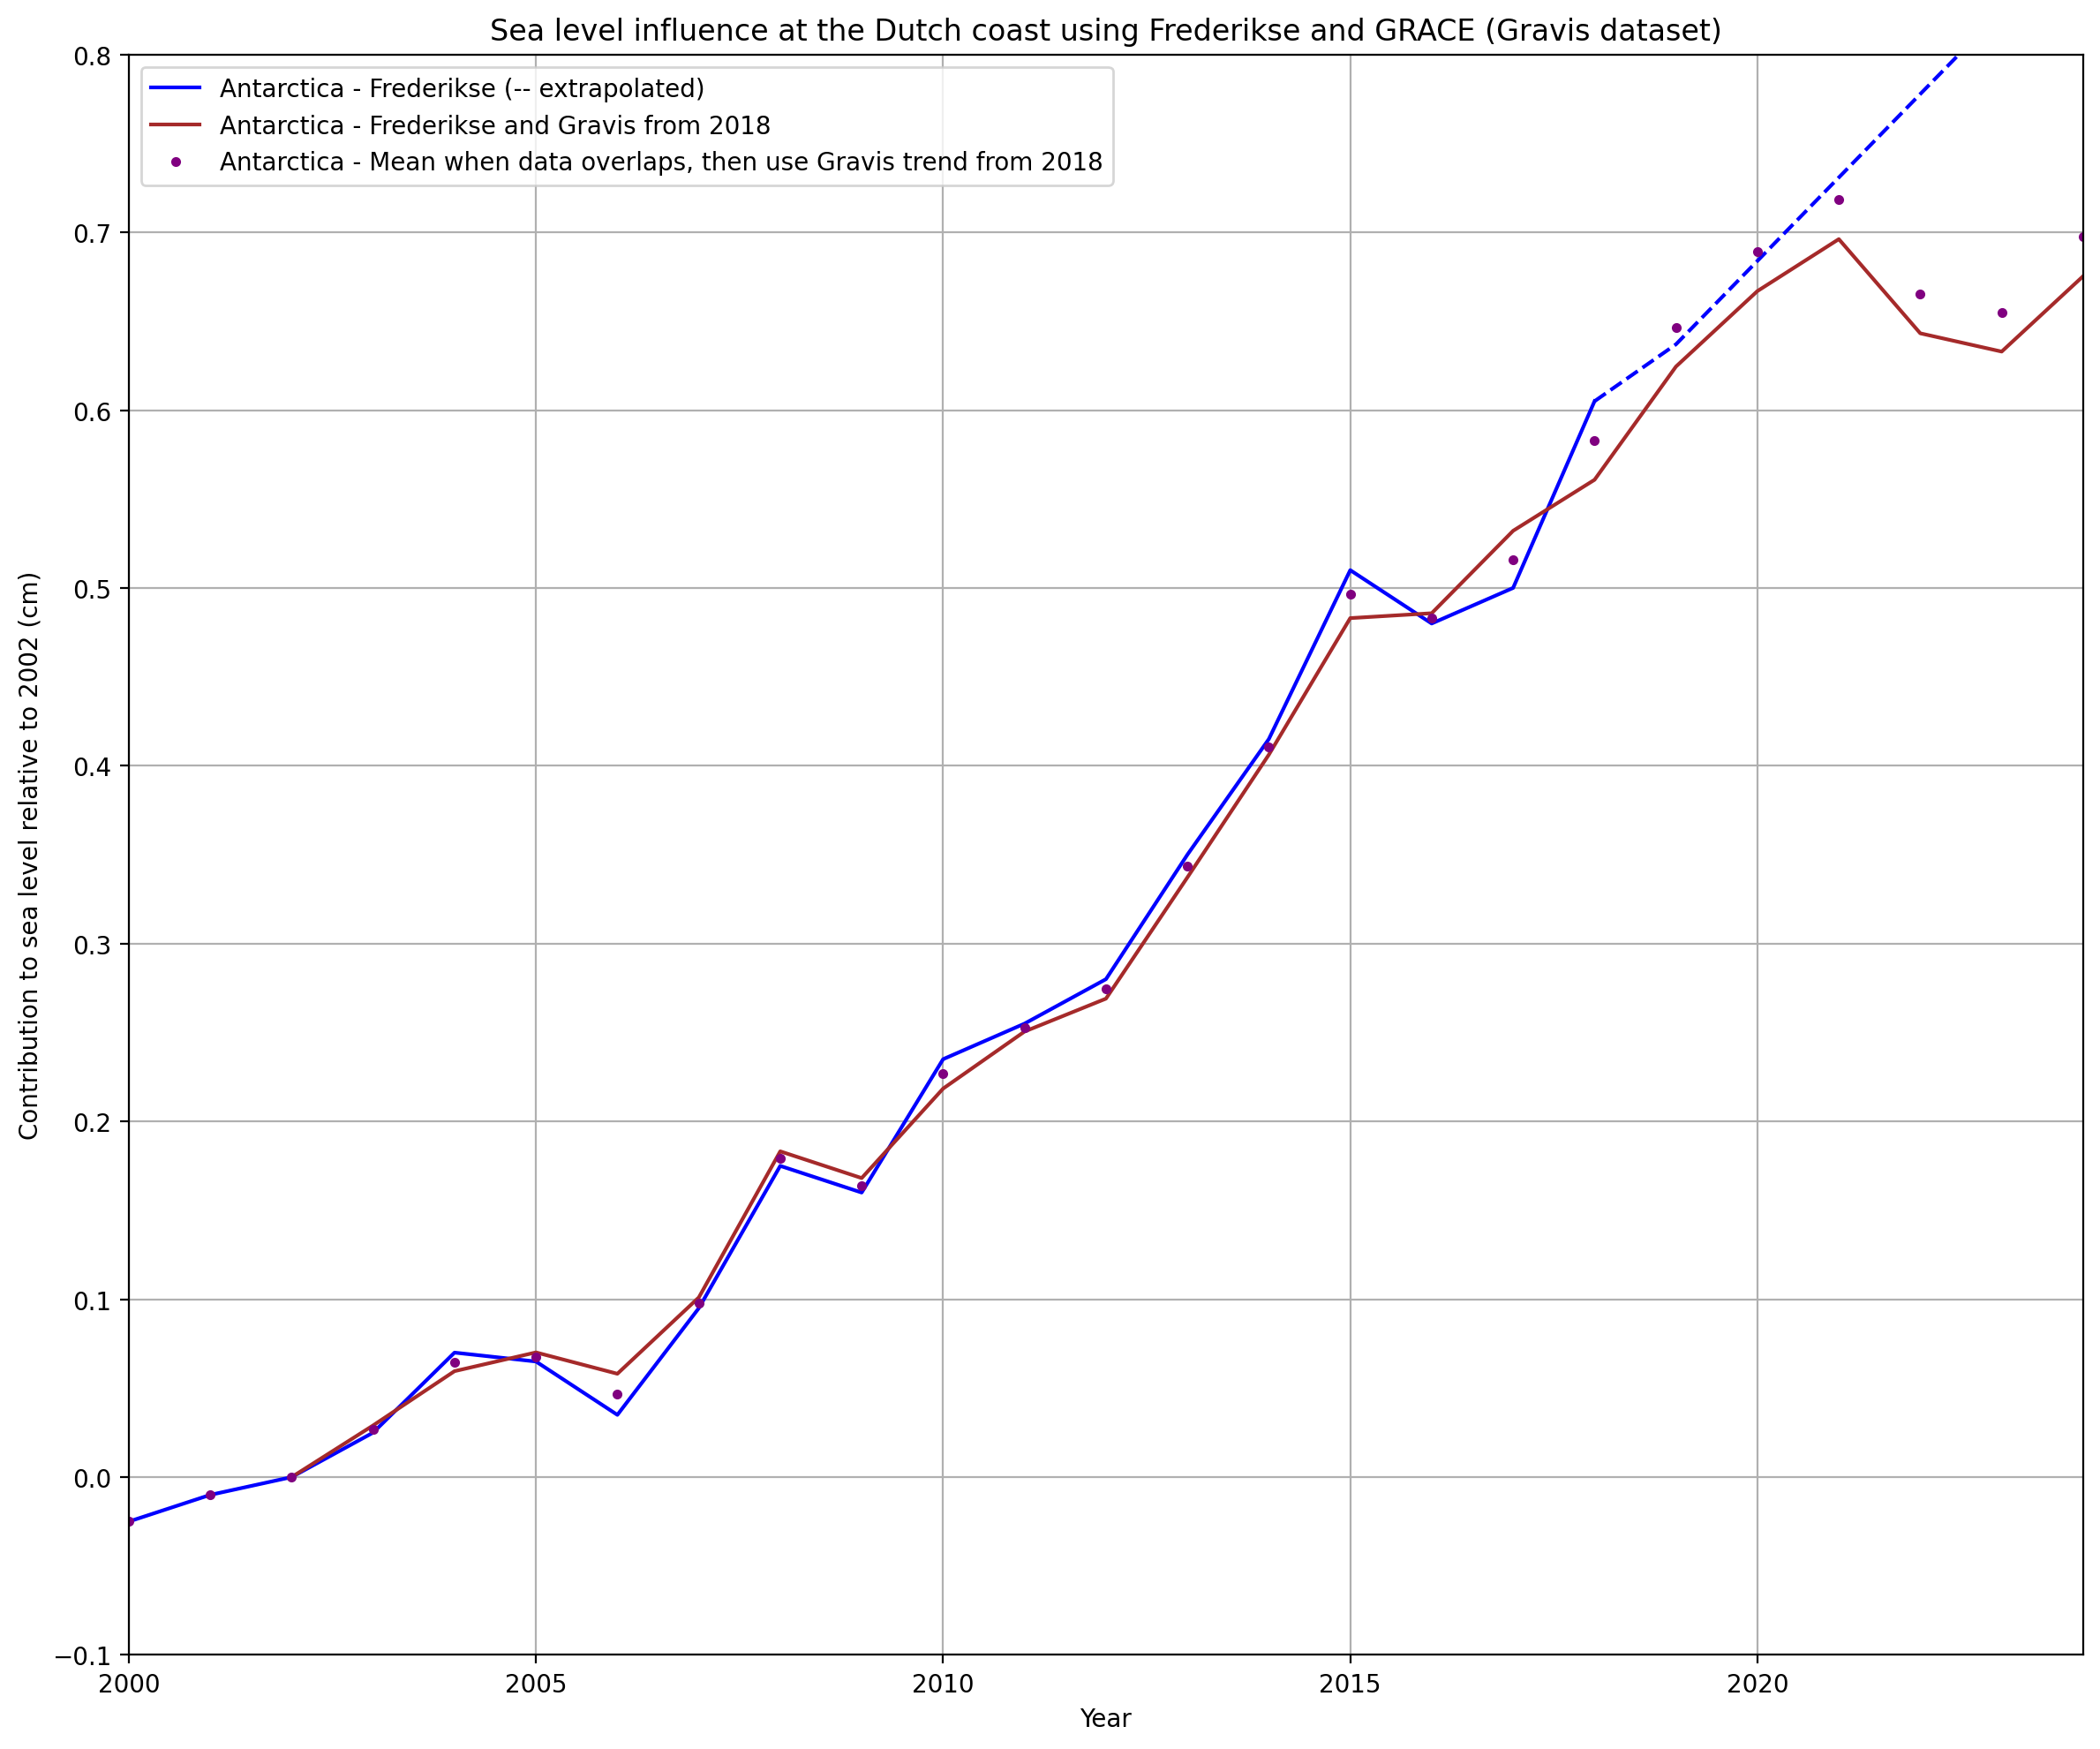

In [12]:
plt.figure(figsize=(12,10))

# Plot each series relative to 2002 from mean_df
#plt.plot(mean_df['TWS_mean'], label='TWS')
plt.plot((mean_df['Antarctica_mean'] - mean_df['Antarctica_mean'].loc[2002]).loc[:2018] , label='Antarctica - Frederikse (-- extrapolated) ', color='blue')
#plt.plot((mean_df['Greenland_mean'] - mean_df['Greenland_mean'].loc[2002]).loc[:2018] , label='Greenland - Frederikse', color='orange')
plt.plot((mean_df['Antarctica_mean'] - mean_df['Antarctica_mean'].loc[2002]).loc[2018:] , linestyle='--', color='blue')
#plt.plot((mean_df['Greenland_mean'] - mean_df['Greenland_mean'].loc[2002]).loc[2018:] , label='Greenland - Frederikse extrapolated', linestyle='--', color='orange')
#plt.plot(mean_df['Glaciers_mean'] , label='Glaciers')
plt.plot(((mean_df['Ant_gravis_mean'] + mean_df['Antarctica_mean'].loc[2002])- (mean_df['Ant_gravis_mean'].loc[2002] + mean_df['Antarctica_mean'].loc[2002])), color='brown', linestyle='-', label='Antarctica - Frederikse and Gravis from 2018')
#plt.plot(((mean_df['Gre_gravis_mean'] + mean_df["Greenland_mean"].loc[2002]) - (mean_df['Gre_gravis_mean'].loc[2002] + mean_df["Greenland_mean"].loc[2002])), color='red', linestyle='-', label='Greenland - Frederikse and Gravis from 2018')
plt.plot(Ant_combined - Ant_combined.loc[2002], label='Antarctica - Mean when data overlaps, then use Gravis trend from 2018', marker='.', linestyle='', color='purple') 
#plt.plot(Gre_combined - Gre_combined.loc[2002], label='Greenland - Mean when data overlaps, then use Gravis trend from 2018', marker='.', linestyle='' ,color='green') 

#plt.plot(Ant_simplecombi - Ant_simplecombi.loc[2002], label='Frederikse and from 2018 only Gravis', color='green', linestyle='--')
#plt.plot(Gre_simplecombi - Gre_simplecombi.loc[2002], label='Frederikse and from 2018 only Gravis', color='cyan', linestyle='--')


plt.xlabel('Year')
plt.ylabel('Contribution to sea level relative to 2002 (cm)')
plt.title('Sea level influence at the Dutch coast using Frederikse and GRACE (Gravis dataset)')
plt.legend()
plt.grid(True)
plt.xlim(2000,2024)
plt.ylim(-0.10, 0.8)
plt.tight_layout()
plt.show()


np.float64(0.35440801667124944)

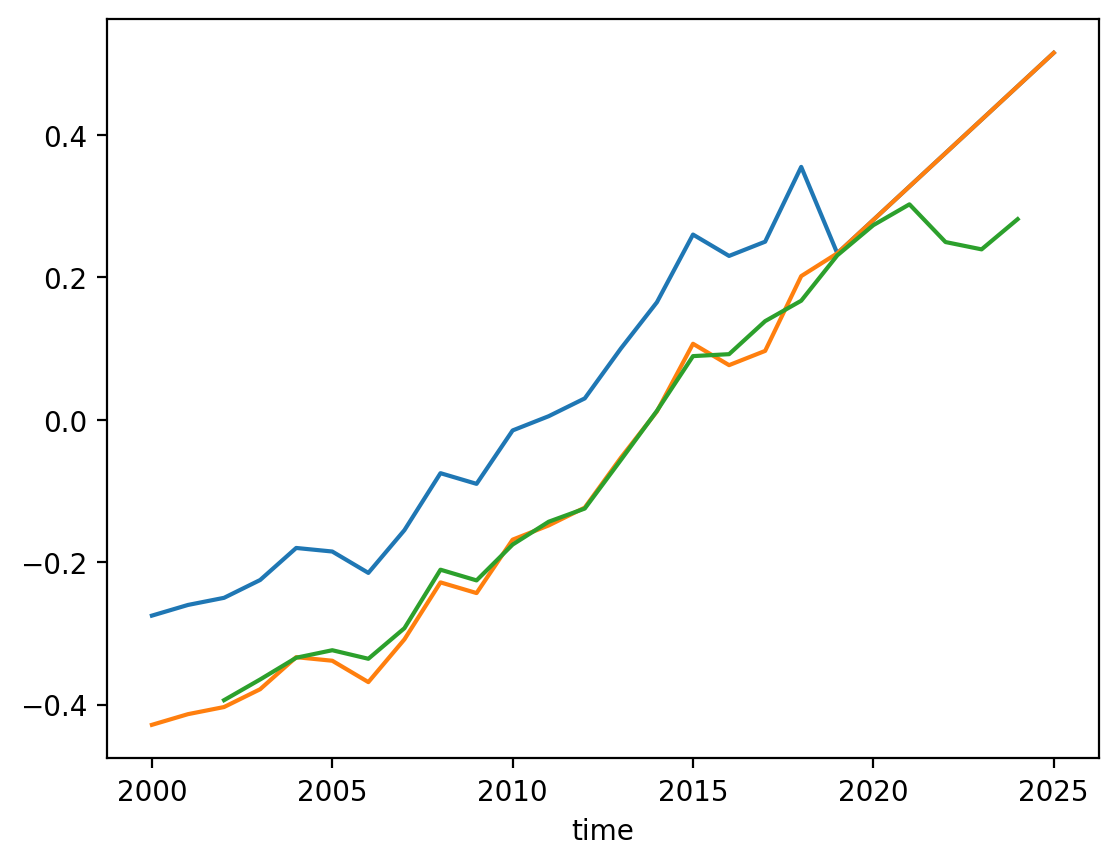

In [23]:
Ant_simplecombi = mean_df['Antarctica_mean'].copy()
Ant_simplecombi.loc[2019:] = mean_df['Antarctica_mean'].loc[2019:] - mean_df['Antarctica_mean'].loc[2010:2018].mean()

Gre_simplecombi = mean_df['Greenland_mean'].copy()

Ant_simplecombi.loc[2000:].plot()
(mean_df['Antarctica_mean'].loc[2000:] - mean_df['Antarctica_mean'].loc[2010:2018].mean()).plot()
(mean_df['Ant_gravis_mean'].loc[2000:] - mean_df['Ant_gravis_mean'].loc[2010:2018].mean()).plot()

mean_df['Ant_gravis_mean'].loc[2000:2024].mean()


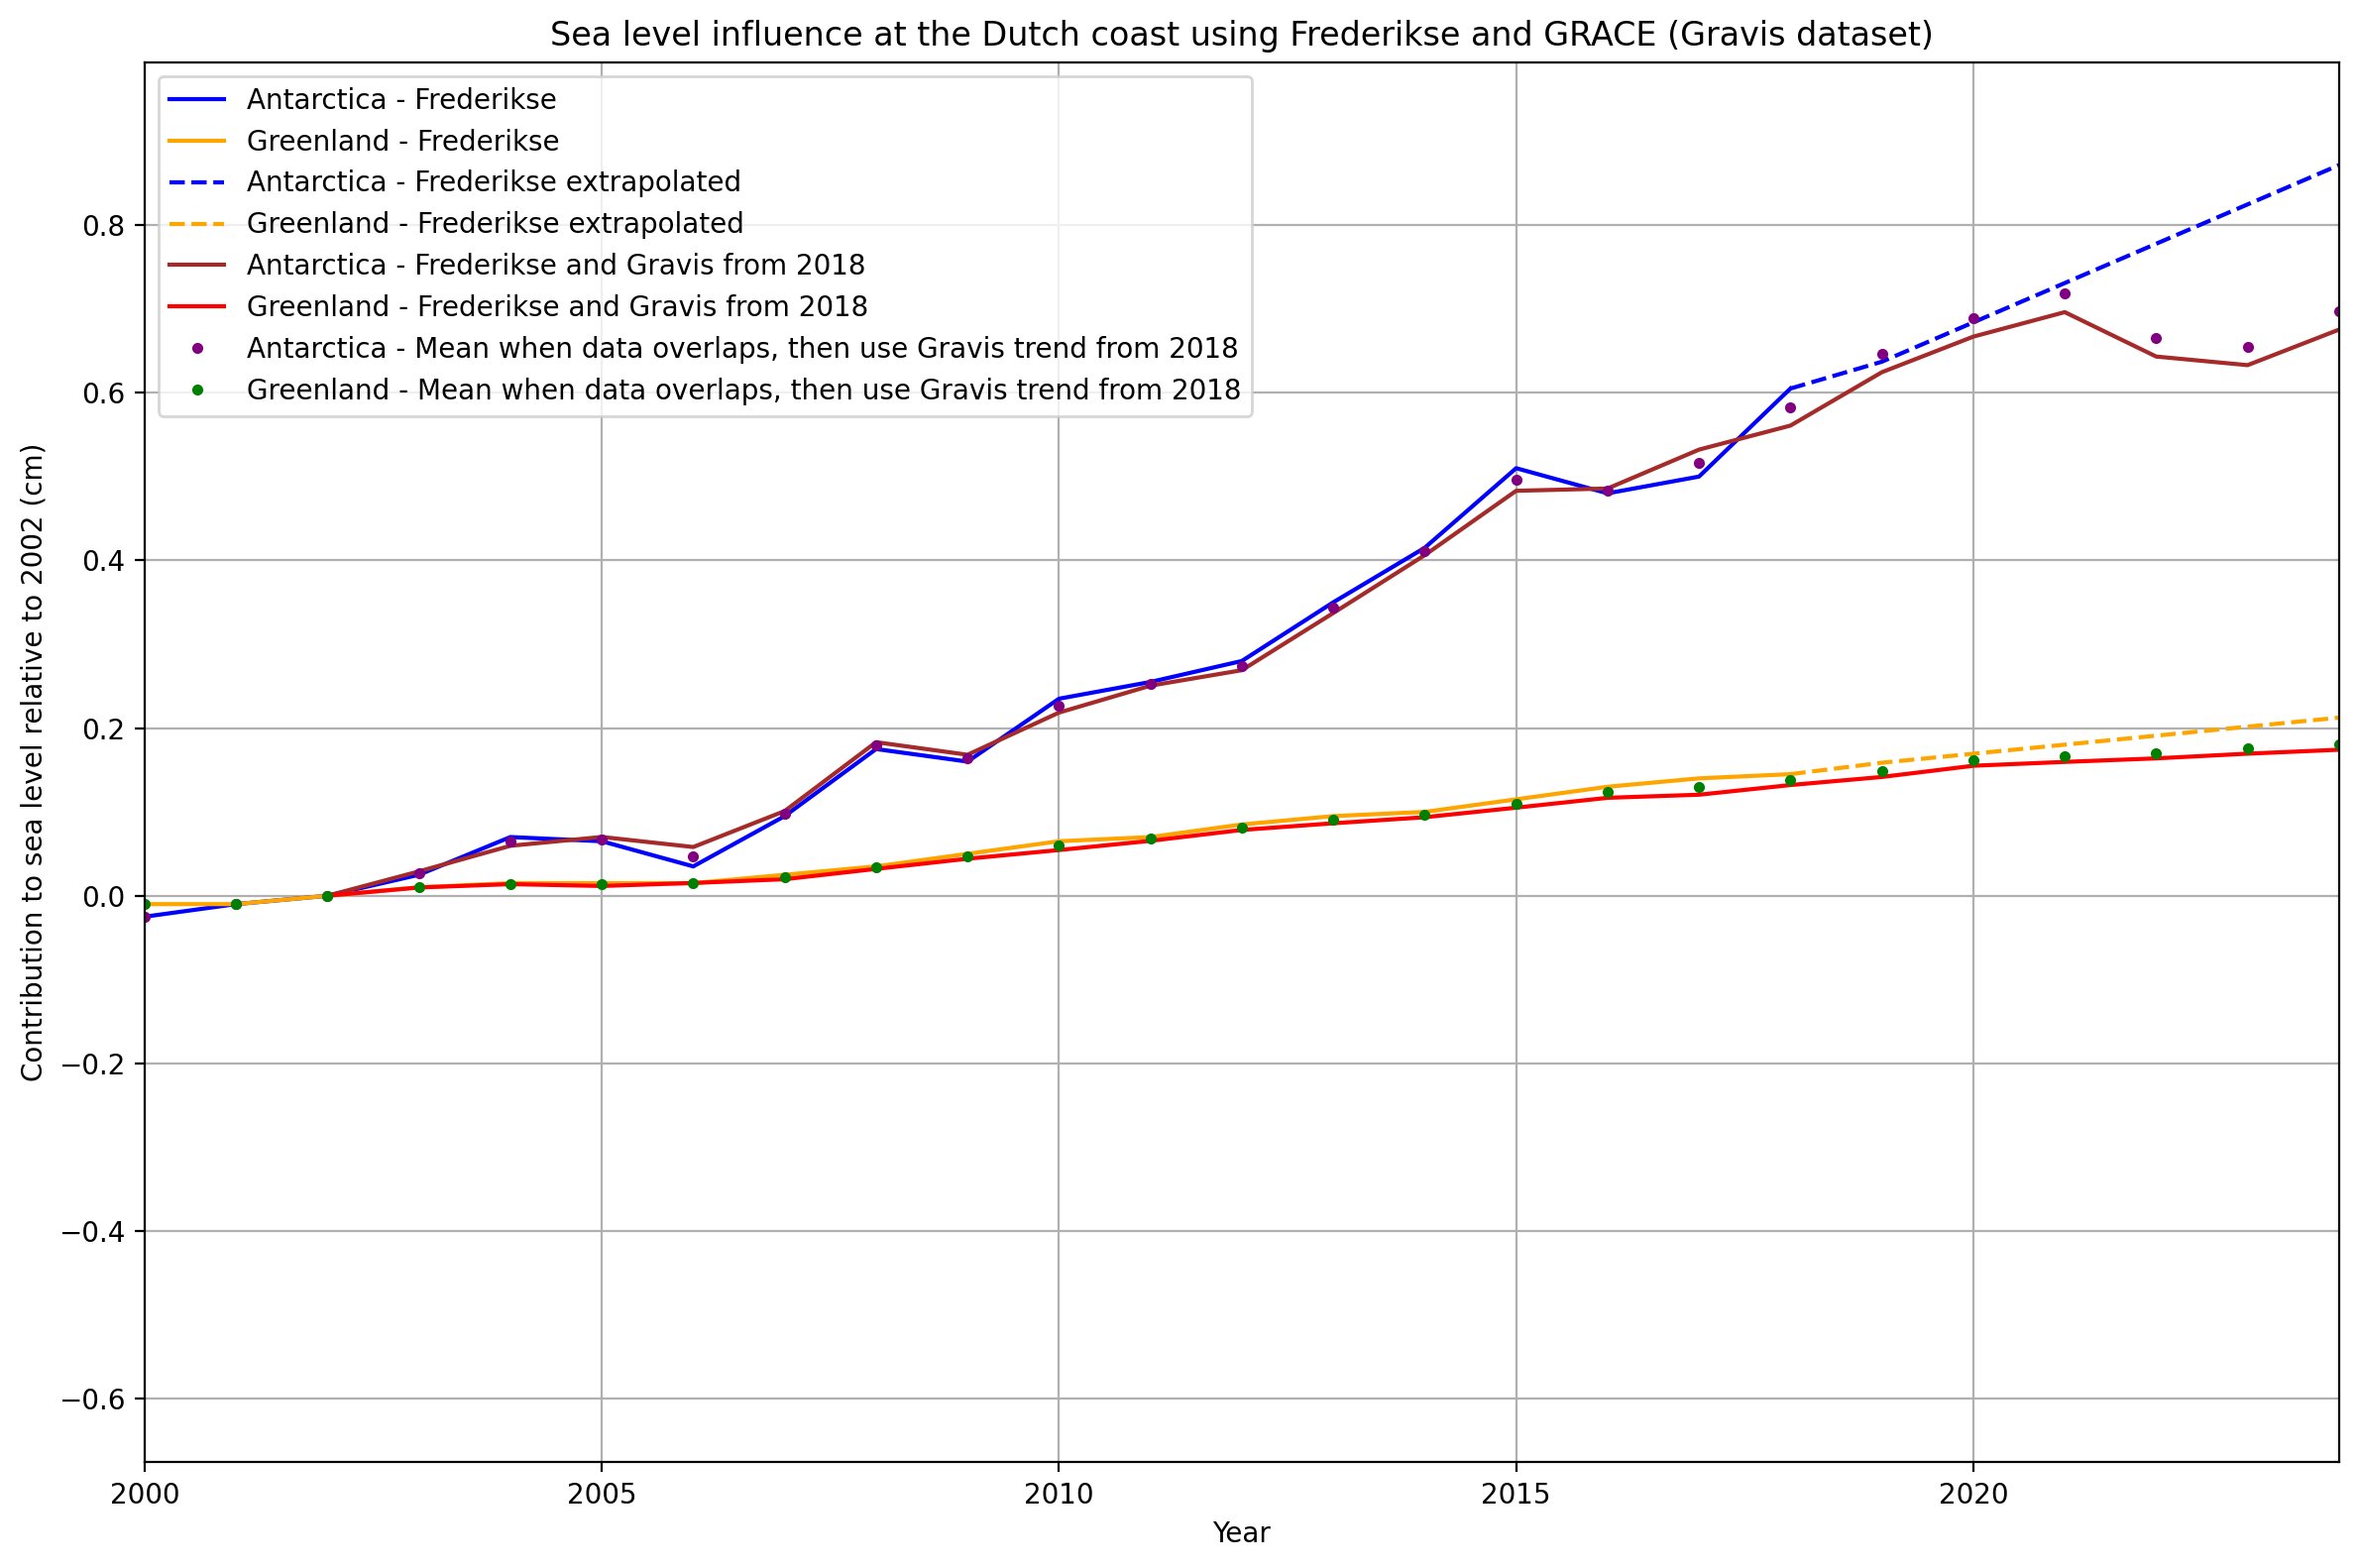

In [14]:
plt.figure(figsize=(12,8))

# Plot each series relative to 2002 from mean_df
#plt.plot(mean_df['TWS_mean'], label='TWS')
plt.plot((mean_df['Antarctica_mean'] - mean_df['Antarctica_mean'].loc[2002]).loc[:2018] , label='Antarctica - Frederikse', color='blue')
plt.plot((mean_df['Greenland_mean'] - mean_df['Greenland_mean'].loc[2002]).loc[:2018] , label='Greenland - Frederikse', color='orange')
plt.plot((mean_df['Antarctica_mean'] - mean_df['Antarctica_mean'].loc[2002]).loc[2018:] , label='Antarctica - Frederikse extrapolated', linestyle='--', color='blue')
plt.plot((mean_df['Greenland_mean'] - mean_df['Greenland_mean'].loc[2002]).loc[2018:] , label='Greenland - Frederikse extrapolated', linestyle='--', color='orange')
#plt.plot(mean_df['Glaciers_mean'] , label='Glaciers')
plt.plot(((mean_df['Ant_gravis_mean'] + mean_df['Antarctica_mean'].loc[2002])- (mean_df['Ant_gravis_mean'].loc[2002] + mean_df['Antarctica_mean'].loc[2002])), color='brown', linestyle='-', label='Antarctica - Frederikse and Gravis from 2018')
plt.plot(((mean_df['Gre_gravis_mean'] + mean_df["Greenland_mean"].loc[2002]) - (mean_df['Gre_gravis_mean'].loc[2002] + mean_df["Greenland_mean"].loc[2002])), color='red', linestyle='-', label='Greenland - Frederikse and Gravis from 2018')
plt.plot(Ant_combined - Ant_combined.loc[2002], label='Antarctica - Mean when data overlaps, then use Gravis trend from 2018', marker='.', linestyle='', color='purple') 
plt.plot(Gre_combined - Gre_combined.loc[2002], label='Greenland - Mean when data overlaps, then use Gravis trend from 2018', marker='.', linestyle='' ,color='green') 

plt.xlabel('Year')
plt.ylabel('Contribution to sea level relative to 2002 (cm)')
plt.title('Sea level influence at the Dutch coast using Frederikse and GRACE (Gravis dataset)')
plt.legend()
plt.grid(True)
plt.xlim(2000,2024)
#lt.ylim(0.4, 0.9)
plt.tight_layout()
plt.show()


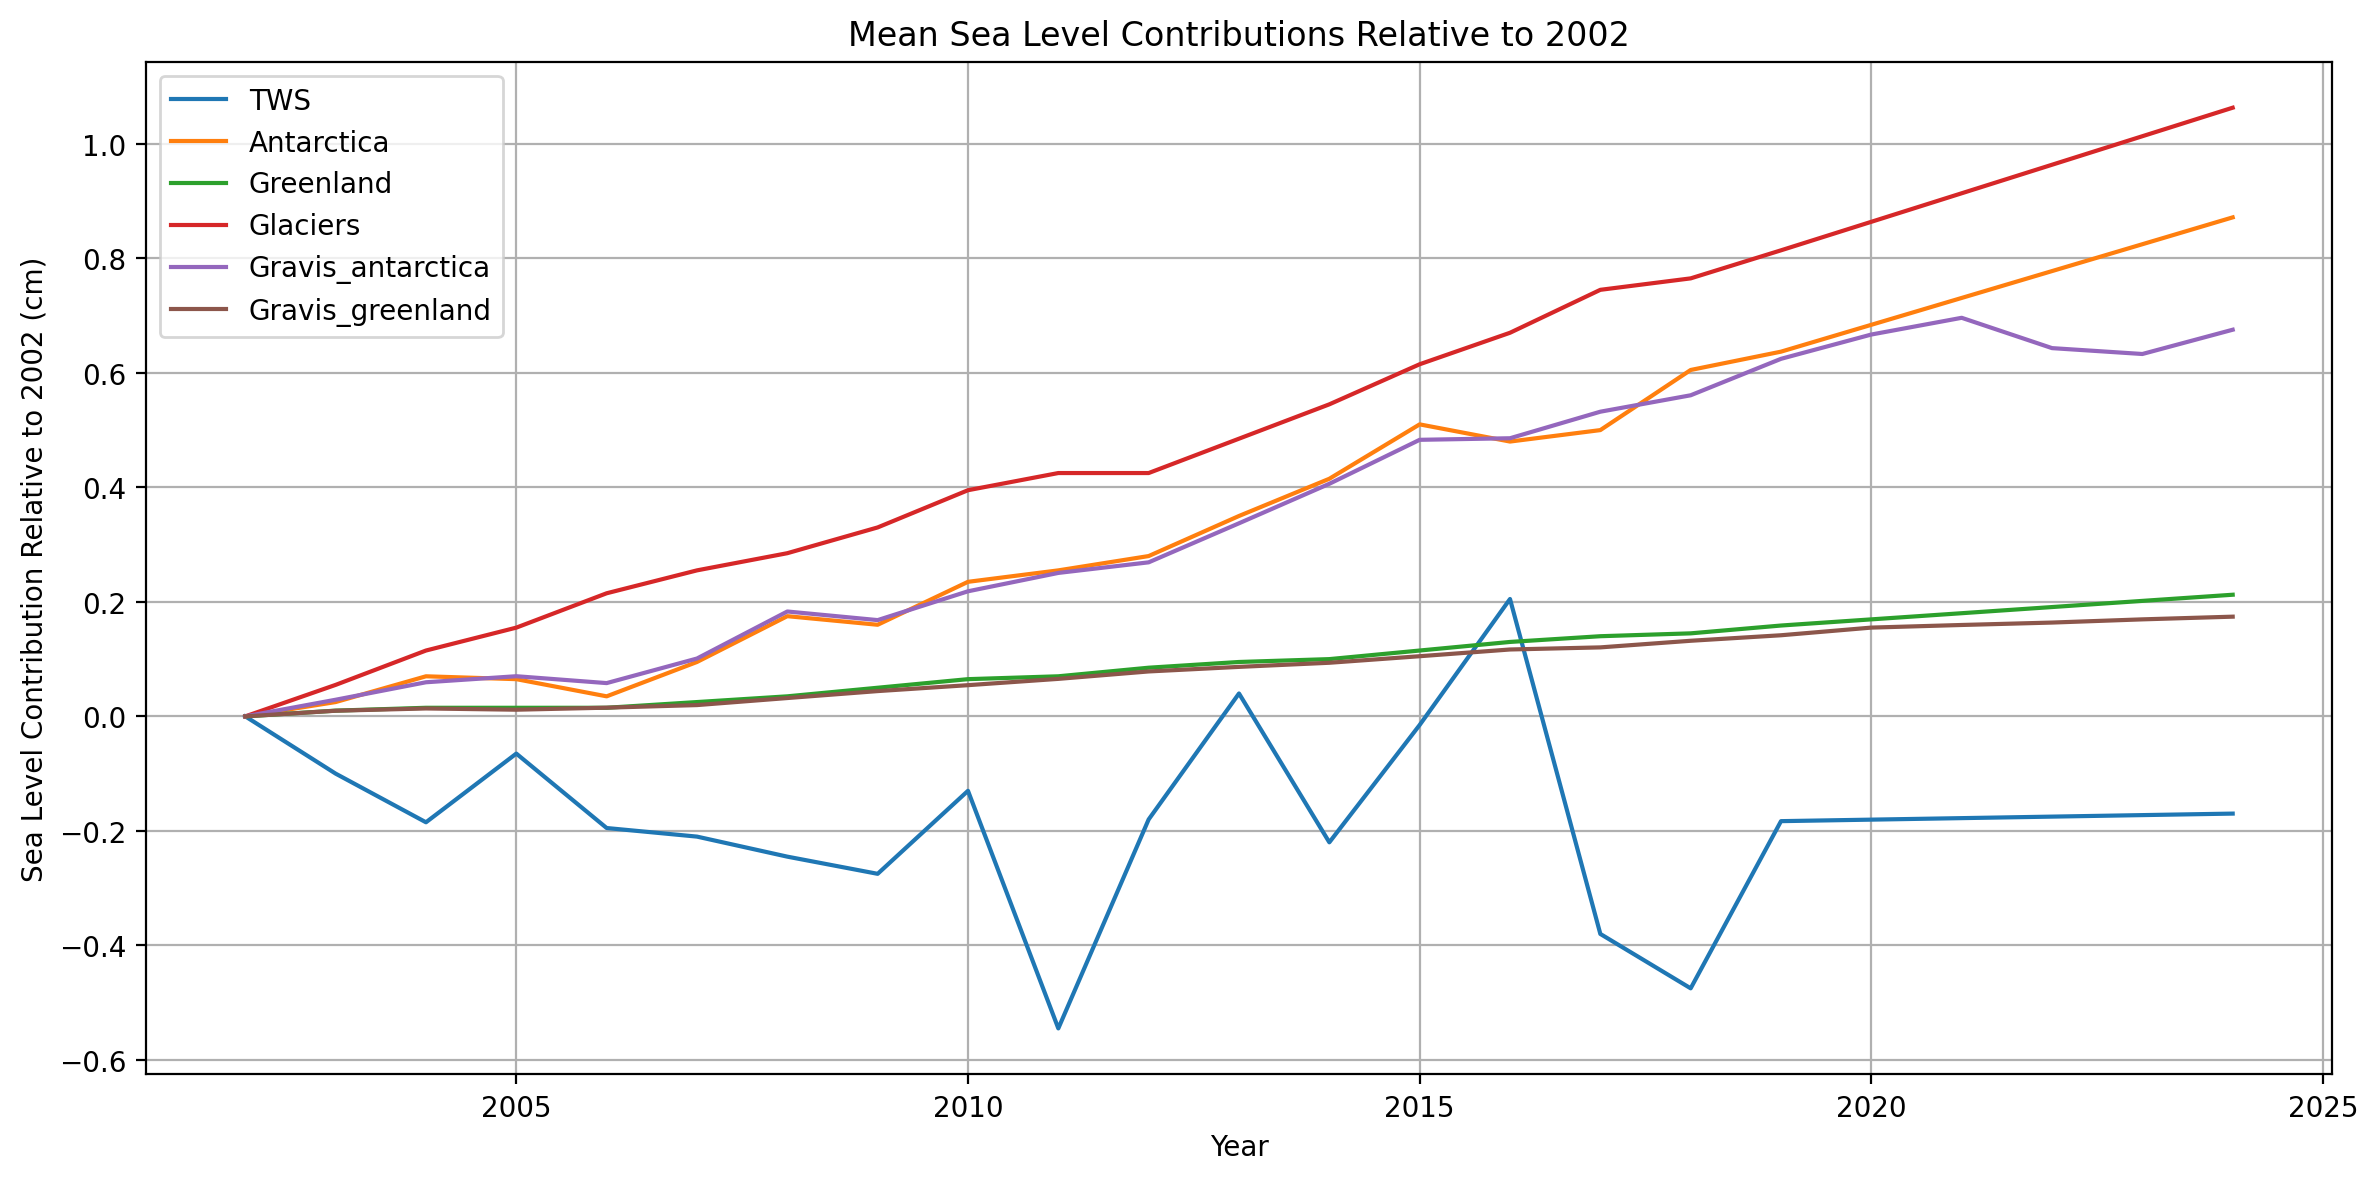

In [15]:
# Filter the years 2002–2024
mean_df_filtered = mean_df.loc[(mean_df.index >= 2002) & (mean_df.index <= 2024)]


# Define the reference year (or custom value) for each series
ref_vals = {
    'TWS': 2002,
    'Antarctica': 2002,
    'Greenland': 2002,
    'Glaciers': 2002,
    'Gravis_antarctica': 2002,
    'Gravis_greenland': 2002
}

plt.figure(figsize=(12,6))

# Plot each series relative to 2002 from mean_df
plt.plot((mean_df_filtered['TWS_mean'] - mean_df_filtered['TWS_mean'].loc[2002]).loc[2002:], label='TWS')
plt.plot((mean_df_filtered['Antarctica_mean'] - mean_df_filtered['Antarctica_mean'].loc[2002]).loc[2002:], label='Antarctica')
plt.plot((mean_df_filtered['Greenland_mean'] - mean_df_filtered['Greenland_mean'].loc[2002]).loc[2002:], label='Greenland')
plt.plot((mean_df_filtered['Glaciers_mean'] - mean_df_filtered['Glaciers_mean'].loc[2002]).loc[2002:], label='Glaciers')
plt.plot((mean_df_filtered['Ant_gravis_mean'] - mean_df_filtered['Ant_gravis_mean'].loc[2002]).loc[2002:], label='Gravis_antarctica')
plt.plot((mean_df_filtered['Gre_gravis_mean'] - mean_df_filtered['Gre_gravis_mean'].loc[2002]).loc[2002:], label='Gravis_greenland')

plt.xlabel('Year')
plt.ylabel('Sea Level Contribution Relative to 2002 (cm)')
plt.title('Mean Sea Level Contributions Relative to 2002')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


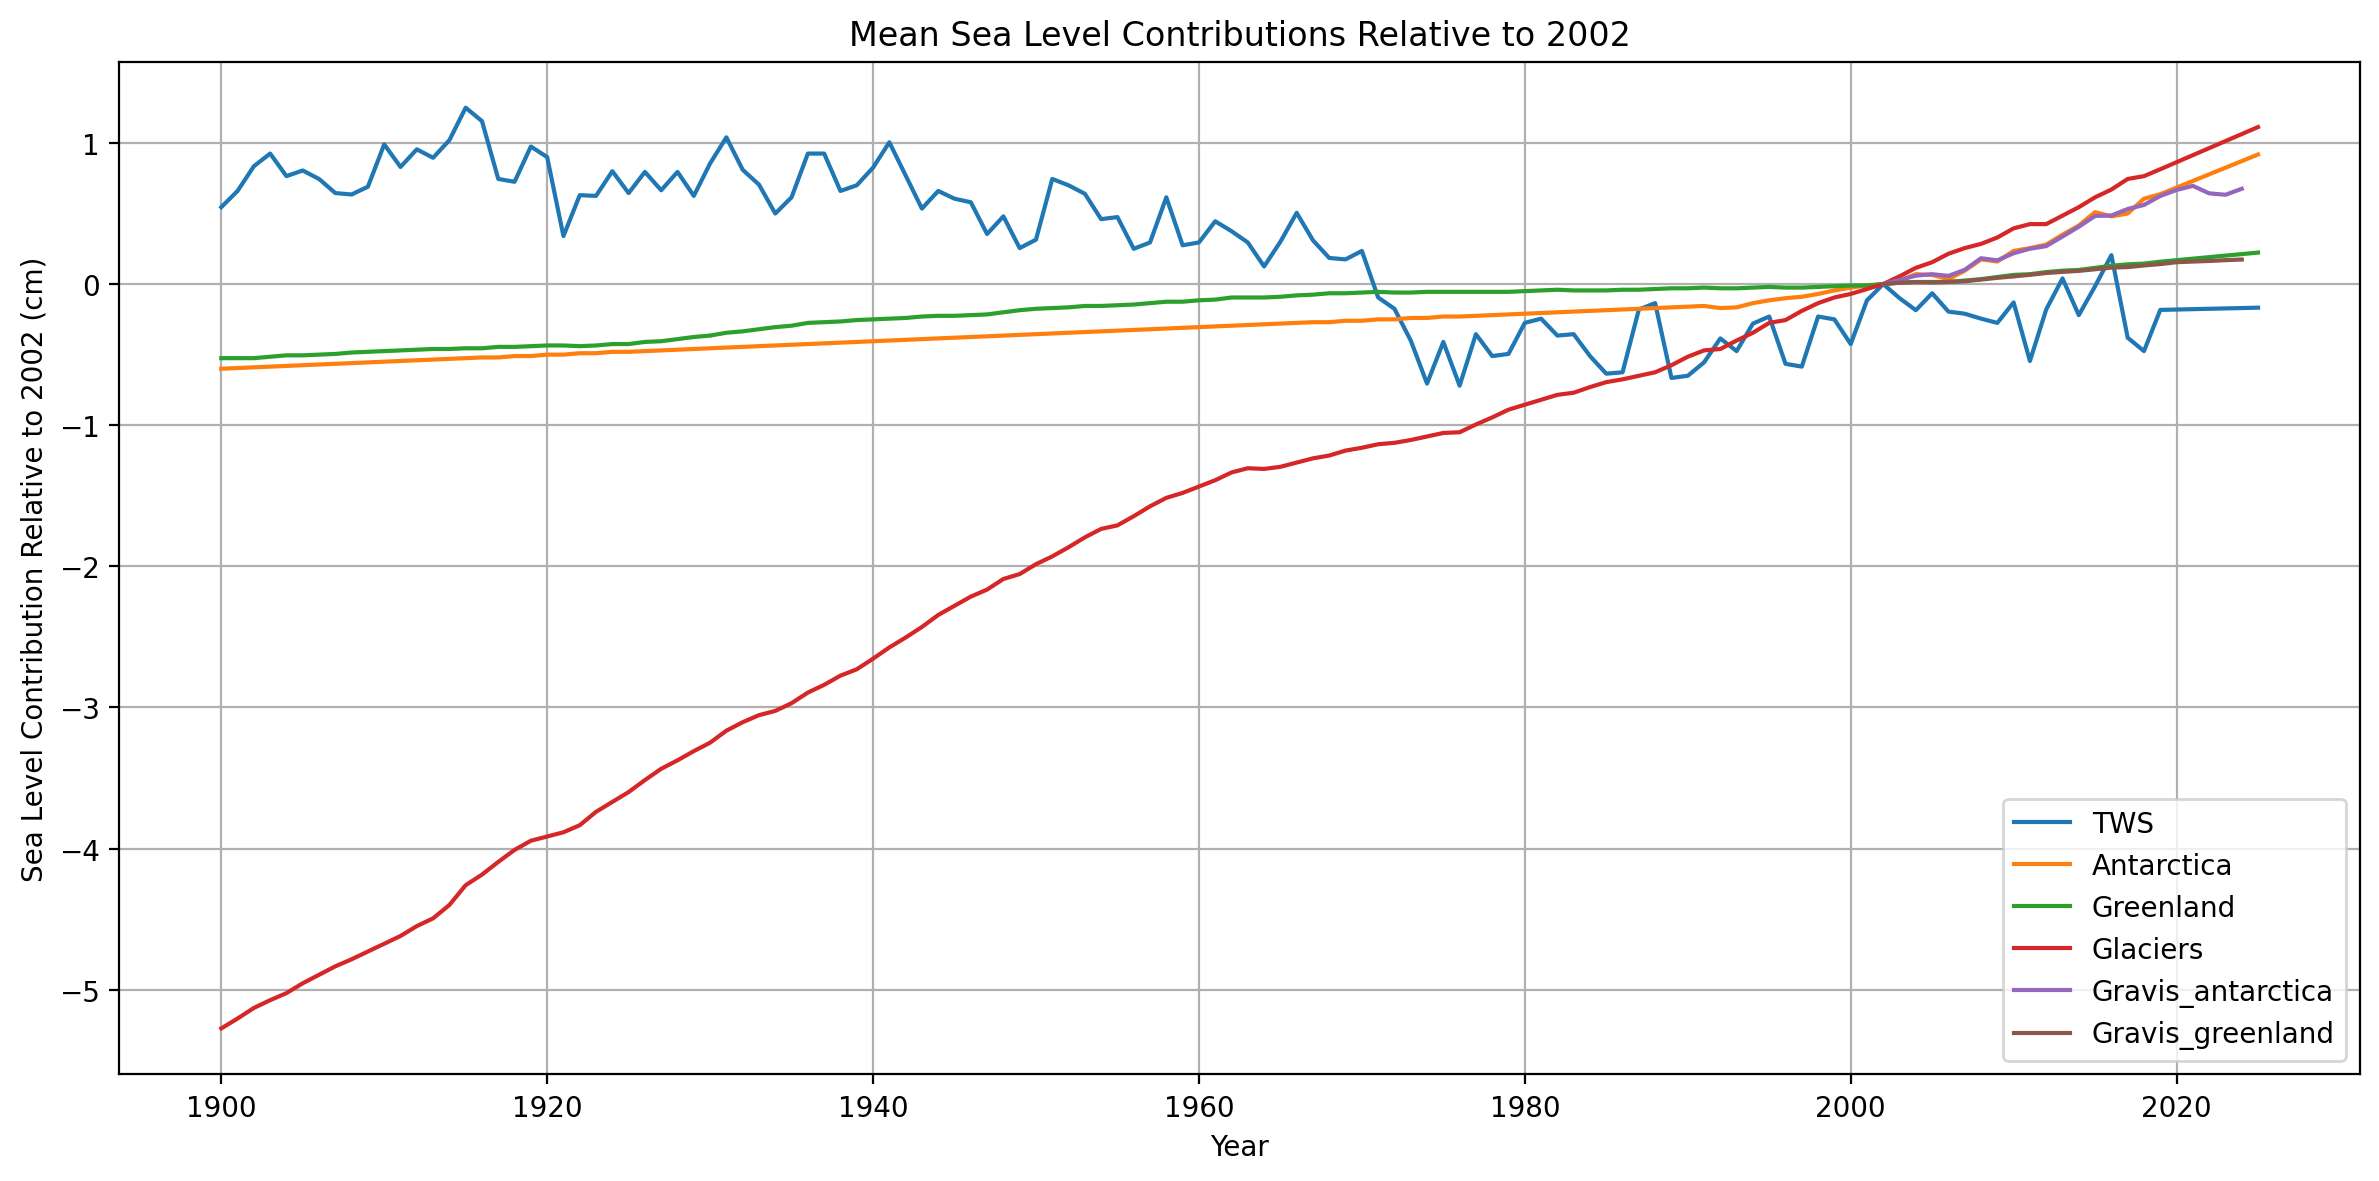

In [16]:
plt.figure(figsize=(12,6))

# Plot each series relative to 2002 from mean_df
plt.plot((mean_df['TWS_mean'] - mean_df['TWS_mean'].loc[2002]), label='TWS')
plt.plot((mean_df['Antarctica_mean'] - mean_df['Antarctica_mean'].loc[2002]), label='Antarctica')
plt.plot((mean_df['Greenland_mean'] - mean_df['Greenland_mean'].loc[2002]), label='Greenland')
plt.plot((mean_df['Glaciers_mean'] - mean_df['Glaciers_mean'].loc[2002]), label='Glaciers')
plt.plot((mean_df['Ant_gravis_mean'] - mean_df['Ant_gravis_mean'].loc[2002]), label='Gravis_antarctica')
plt.plot((mean_df['Gre_gravis_mean'] - mean_df['Gre_gravis_mean'].loc[2002]), label='Gravis_greenland')

plt.xlabel('Year')
plt.ylabel('Sea Level Contribution Relative to 2002 (cm)')
plt.title('Mean Sea Level Contributions Relative to 2002')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
# Test for in sealevelcontrib

fredant_df = slc.contrib_frederikse2020(tg_coord, 'AIS',
                                extrap=True)



Gravis_dir = '../outputs/Gravis_Antarctica/'
Gravis_ant_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Ant_new_weighted.nc')
sel_da = Gravis_ant_ds['AIS_Gravis'].ffill('lon', 3).bfill('lon', 3)

loc_da = sel_da.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')
fr_name = {
    'tws' : 'TWS', 
    'AIS' : 'Antarctica', 
    'GrIS' : 'Greenland', 
    'glac' : 'Glaciers',
    'grav': 'Ant_gravis'}
ant_df = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav']) 
ant_df = ant_df*1.2 #for now corrected... 

# now combine the two by taking frederikse for data before 2002, taking the 
display(fredant_df.loc[2002:])
#print(ant_df.loc[2002:])


,Antarctica
time,
2002,-0.250000
2003,-0.220000
2004,-0.175000
2005,-0.185000
2006,-0.210000
2007,-0.155000
2008,-0.075000
2009,-0.090000
2010,-0.015000


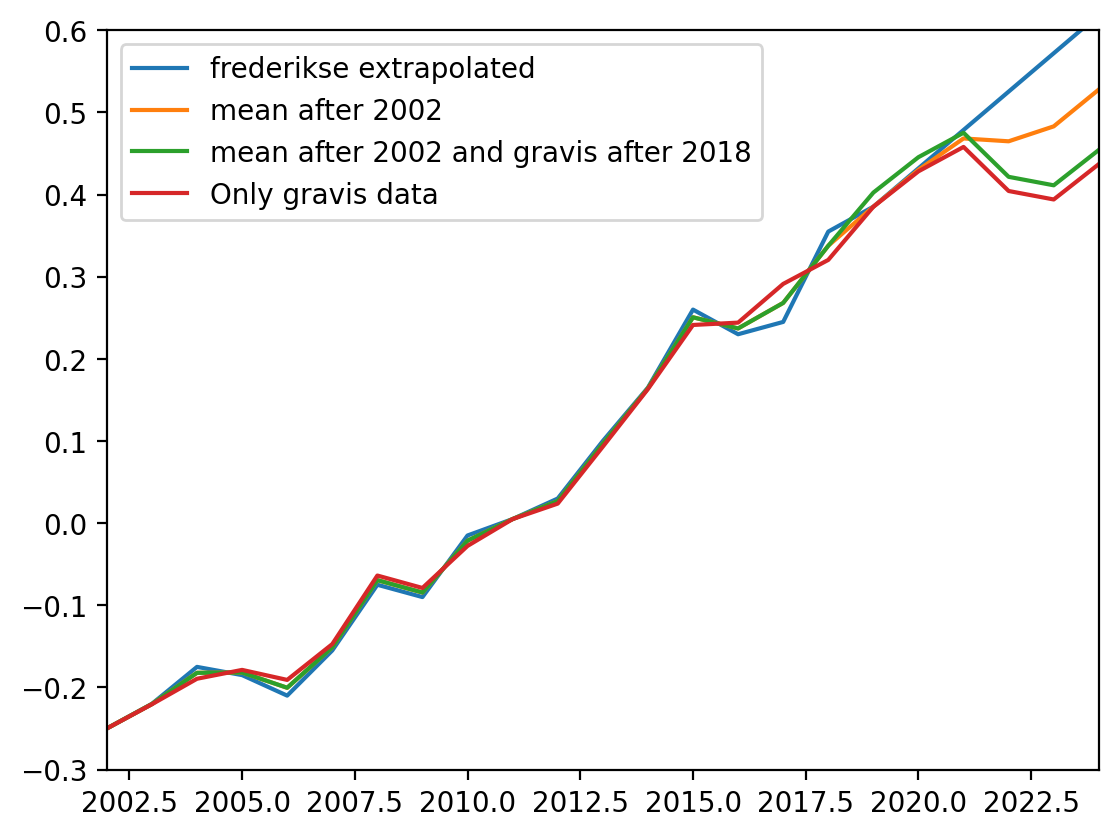

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


time
1900   -0.845000
1901   -0.840000
1902   -0.835000
1903   -0.830000
1904   -0.830000
          ...   
2021    0.475326
2022    0.421666
2023    0.411335
2024    0.454408
2025         NaN
Name: Antarctica, Length: 126, dtype: float64

In [18]:
#Ant_combined = mean_df['Antarctica_mean'].copy()
#Ant_combined.loc[2002:] = ((mean_df['Ant_gravis_mean'] + mean_df['Antarctica_mean'].loc[2002]) + mean_df['Antarctica_mean'])/2  #takes the mean where there is data twice
#Ant_combined.loc[2018:] = mean_df['Ant_gravis_mean'] - mean_df['Ant_gravis_mean'].loc[2018] + Ant_combined.loc[2018]  # from 2018, take gravis data but force 2018 on the mean
#fredant_df = mean_df['Antarctica_mean']
#ant_df = mean_df['ant_gravis_mean']


Antcombi = fredant_df['Antarctica'].copy()
plt.plot(Antcombi, label='frederikse extrapolated')
Antcombi.loc[2002:] = ((ant_df['Ant_gravis'] + fredant_df['Antarctica'].loc[2002]) + fredant_df['Antarctica'])/2
plt.plot(Antcombi, label= 'mean after 2002')
Antcombi.loc[2018:] = ant_df['Ant_gravis'] - ant_df['Ant_gravis'].loc[2018] + Antcombi.loc[2018] 
plt.plot(Antcombi, label= 'mean after 2002 and gravis after 2018')
plt.plot(ant_df['Ant_gravis'] + fredant_df['Antarctica'].loc[2002], label='Only gravis data')
plt.xlim(2002, 2024)
plt.ylim(-0.3, 0.6)
plt.legend()
plt.show()
#display(mean_df['Ant_gravis_mean'])
#display(ant_df['Ant_gravis'])
print(type(Antcombi))
print(type(ant_df))
display(Antcombi)
Antcombi = Antcombi.to_frame()

#display(Antcombi)


#is it datarame or xr

In [19]:

# Combine Frederikse data and Gravis
fredant_df = slc.contrib_frederikse2020(tg_coord, 'AIS', output_type, extrap=True)  #first find the frederikse values. 

Gravis_dir = '../outputs/Gravis_Antarctica/'
Gravis_ant_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Ant_clean.nc')
sel_da = Gravis_ant_ds['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)

loc_da = sel_da.sel(lat = coord[0], 
                    lon = coord[1], 
                    method = 'nearest')

gravis_df = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name='Ant_gravis') 
gravis_df = gravis_df*1.1837950465122913 # For now apply the correction. . 

# now combine the two by taking frederikse for data before 2002, taking the mean between 2002 and 2018 and using Gravis after from 2018 and after. 

Antcombi = fredant_df['Antarctica'].copy()
Antcombi.loc[2002:] = ((gravis_df['Ant_gravis'] + fredant_df['Antarctica'].loc[2002]) + fredant_df['Antarctica'])/2
Antcombi.loc[2018:] = gravis_df['Ant_gravis'] - gravis_df['Ant_gravis'].loc[2018] + Antcombi.loc[2018] 

#Antcombi= Antcombi.loc[:2024]
ant_df = Antcombi.to_frame()
            

NameError: name 'output_type' is not defined